In [1]:
import jax.numpy as jnp
from jax import vmap
from jax.scipy import linalg
from jax import random
import matplotlib.pyplot as plt

from lqg import System, Dynamics, Actor
from lqg import xcorr
from lqg.belief import kf
from lqg.control import lqr

In [2]:
class SubjectiveController(System):
    def __init__(self, dim=1, process_noise=1., action_cost=1., action_variability=0.5, subj_control_gain=1.0,
                 sigma_target=6., sigma_cursor=6., dt=1. / 60, T=1000):
        A = jnp.eye(2 * dim)
        B = linalg.block_diag(*[jnp.array([[0.], [10. * dt]])] * dim)
        F = jnp.eye(2 * dim)

        V = linalg.block_diag(*[jnp.diag(jnp.array([process_noise, action_variability]))] * dim)
        W = linalg.block_diag(*[jnp.diag(jnp.array([sigma_target, sigma_cursor]))] * dim)

        dyn = Dynamics(A=A, B=B, F=F, V=V, W=W, T=T)

        B = linalg.block_diag(*[jnp.array([[0.], [subj_control_gain * 10. * dt]])] * dim)


        Q = linalg.block_diag(*[jnp.array([[1., -1.], [-1., 1.]])] * dim)
        R = jnp.eye(B.shape[1]) * action_cost

        act = Actor(A=A, B=B, F=F, V=V, W=W, Q=Q, R=R, T=T)

        super().__init__(actor=act, dynamics=dyn)


Text(0, 0.5, 'Cross-correlation')

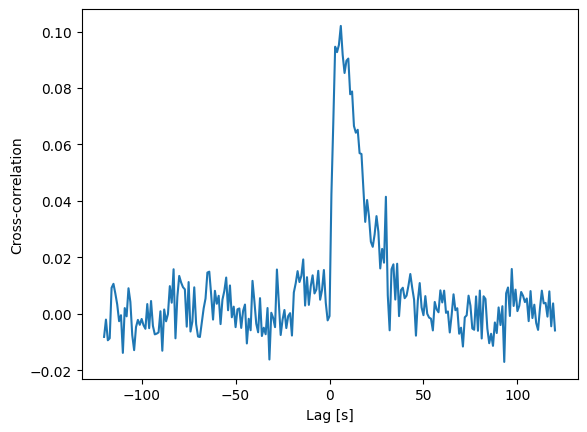

In [10]:
model = SubjectiveController(subj_control_gain=1.)

x = model.simulate(rng_key=random.PRNGKey(0), n=20)

vels = jnp.diff(x, axis=1)
lags, correls = xcorr(vels[...,1], vels[...,0], maxlags=120)

plt.plot(lags, correls.mean(axis=0))
plt.xlabel("Lag [s]")
plt.ylabel("Cross-correlation")

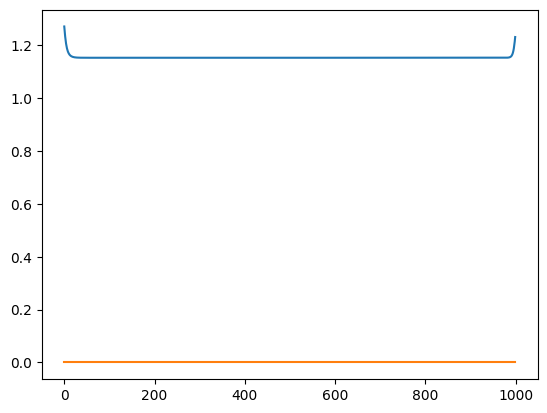

In [11]:
gains = lqr.backward(model.actor)
K = kf.forward(model.actor, Sigma0=model.actor.V[0] @ model.actor.V[0].T)

old_terms = model.actor.A + model.actor.B @ gains.L - K @ model.actor.F @ model.actor.A
new_terms = (
    K @ (model.dynamics.F @ model.dynamics.B - model.actor.F @ model.actor.B) @ gains.L
)

plt.plot(vmap(jnp.linalg.norm)(old_terms))
plt.plot(vmap(jnp.linalg.norm)(new_terms))

In [12]:
subj_control_gains = jnp.logspace(-3, 3)

ll = vmap(lambda s: SubjectiveController(subj_control_gain=s).log_likelihood(x).sum())(subj_control_gains)
ll.shape

(50,)

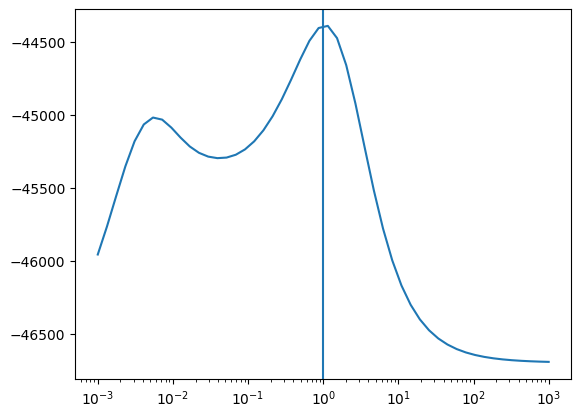

In [13]:
plt.plot(subj_control_gains, ll)
plt.axvline(1.)
plt.xscale("log")

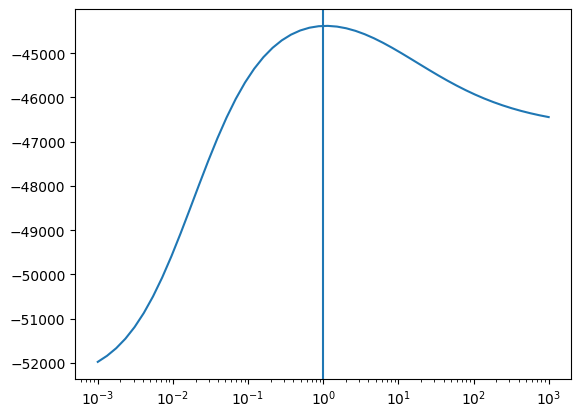

In [ ]:
costs = jnp.logspace(-3, 3)

ll = vmap(lambda s: SubjectiveController(action_cost=s).log_likelihood(x).sum())(costs)
ll.shape

plt.plot(costs, ll)
plt.axvline(1.)